# Test 3 — Adverse selection: does it move the optimal control, and can it be predicted?

## 1. The question

The environment used in Tests 1 and 2 is the one in which the Cartea–Jaimungal (CJ) solution is derived, and in
which it is optimal by construction. This notebook asks what happens when a single assumption is relaxed: that
the market maker's executions are informative about where the price is going next.

Two things must be separated, and the literature routinely conflates them.

| | Question | Answer needed before |
|---|---|---|
| **Presence** | is the factor measurably non-zero in the simulated market? | claiming the environment is richer |
| **Relevance** | does the factor move the *optimal control*, not merely the payoff? | claiming a learned agent could beat the closed form |

A factor can be overwhelmingly significant and still leave the optimal policy unchanged, in which case it can be
dropped from the model without loss. Only the second question justifies carrying the factor into the state.

A third question is separate again and is what decides whether reinforcement learning has anything to contribute:

| | Question |
|---|---|
| **Predictability** | is the factor foreseeable from the observation, or is it an unavoidable tax? |

An unpredictable degradation lowers every policy's payoff and changes the optimal control only through a static
risk trade-off. A predictable one creates a state-dependent control, which is exactly what a closed form derived
without that state cannot express.

## 2. The stochastic control problem

The market maker posts a bid at $S_t - \delta^-_t$ and an ask at $S_t + \delta^+_t$, holds inventory $q_t$ and
cash $X_t$. Writing $N^{\pm}$ for the counting processes of filled limit orders,

$$dq_t = dN^-_t - dN^+_t, \qquad
dX_t = (S_t + \delta^+_t)\,dN^+_t - (S_t - \delta^-_t)\,dN^-_t .$$

The agent maximises the Cartea–Jaimungal criterion, a running penalty on inventory plus a terminal liquidation
penalty:

$$J(\delta) \;=\; \mathbb{E}\Big[\, X_T + q_T S_T \;-\; \varphi \int_0^T q_u^2\,du \;-\; \alpha_{\mathrm{liq}}\, q_T^2 \Big].$$

In the nested environment $E_{\text{closed}}$ the midprice is a driftless Brownian motion, market orders arrive as
independent Poisson processes of intensity $\lambda$, and a resting order at depth $\delta$ is filled by an
arriving market order with probability $e^{-\kappa\delta}$. With the ansatz
$H(t,x,S,q) = x + qS + h_q(t)$ the Hamilton–Jacobi–Bellman equation separates, and the optimal depths are

$$\boxed{\;\delta^{\pm,*}(t,q) \;=\; \frac{1}{\kappa} \;+\; h_q(t) - h_{q\mp 1}(t)\;}$$

with $\omega = e^{\kappa h}$ solving the linear system $\omega' = A\omega$, $A_{qq} = \kappa\varphi q^2$,
$A_{q,q\pm1} = -\lambda e^{-1}$. Three features of this solution matter here.

* It depends on $\kappa$, $\lambda$, $\varphi$, $\alpha_{\mathrm{liq}}$ and on $(t, q)$ — **and on nothing else**.
  In particular it does not depend on $\sigma$, and it has no channel through which any exogenous state could
  enter.
* At $\varphi = \alpha_{\mathrm{liq}} = 0$ it collapses to the constant $\delta^* = 1/\kappa$.
* The half-spread it quotes is therefore $O(1/\kappa)$, a fact section 6 will use.

Everything below asks what this control loses when the environment stops satisfying the assumptions above.

## 3. Two mechanisms of adverse selection

Adverse selection means the price moves against the position the market maker has just taken. Two distinct
mechanisms produce it, and this notebook implements and separates both.

**(a) Informational — the shared latent factor.** A mean-reverting signal $\alpha_t$ drives both the midprice
drift and the *direction* of order flow:

$$dS_t = \alpha_t\,dt + \sigma\,dW_t, \qquad
d\alpha_t = -\zeta\,\alpha_t\,dt + \eta\,dW^\alpha_t,$$

$$\lambda^{\text{sell}}(\alpha) = \lambda_0 e^{-\gamma\alpha}, \qquad
\lambda^{\text{buy}}(\alpha) = \lambda_0 e^{+\gamma\alpha}.$$

When $\alpha_t > 0$ the price drifts up *and* buy market orders become more frequent; they lift the market maker's
ask, which sells just before the rise. The correlation between fills and subsequent price moves is not imposed —
it emerges from the two channels sharing one factor. Because $\alpha$ is part of the observation, this adverse
selection is in principle **predictable**. Setting $\gamma = 0$ recovers the Poisson model exactly, so
$E_{\text{closed}}$ is a nested limit.

**(b) Mechanical — fills forced by the price path.** Lalor and Swishchuk (2024) observe that in the standard
simulator market orders are drawn *independently* of the price, so the midprice can walk straight through a
resting quote without filling it. In a real book that cannot happen. They add fills that are a deterministic
function of the path (their eq. 16–17), which we write for a quote at depth $\delta$:

$$AF^{+}_t = \mathbf{1}\{S_{t+dt} - S_t > \delta^+_t\}, \qquad
AF^{-}_t = \mathbf{1}\{S_t - S_{t+dt} > \delta^-_t\},$$

and thin the remaining, benign fills by a queue-position probability $p$ (their eq. 13–15), combining the two
branches as $N = \max(AF, NF)$ (their eq. 18–19). At the touch, $\delta = 0$, this is exactly their rule.

Mechanism (b) is what makes the simulator honest about how often the market maker is run over. Whether it is also
*predictable* is a separate question, settled in section 7.

> **References.** Cartea, Jaimungal and Penalva (2015), *Algorithmic and High-Frequency Trading*, ch. 10;
> Cartea and Jaimungal (2016), *Incorporating order-flow into optimal execution*; Lalor and Swishchuk (2024),
> *Market Simulation under Adverse Selection*, arXiv:2409.12721.

## 4. Setup

The cell below imports the environment components and fixes the parameters used throughout. A single constructor
`get_env` is parameterised by the two mechanisms, so that every comparison in this notebook changes one thing and
holds the rest fixed — same midprice volatility, same base intensities, same fill exponent, same seeds.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from agents.Agent import Agent
from agents.BaselineAgents import AvellanedaStoikovAgent, CarteaJaimungalMmAgent
from gym_local.ModelDynamics import AdverseFillModelDynamics, LimitOrderModelDynamics
from gym_local.TradingEnvironment import TradingEnvironment
from gym_local.helpers.generate_trajectory import generate_trajectory
from gym_local.index_names import ASK_INDEX, ASSET_PRICE_INDEX, BID_INDEX, CASH_INDEX, INVENTORY_INDEX
from rewards.RewardFunctions import CjMmCriterion
from stochastic_processes.arrival_models import PoissonArrivalModel, StateDependentPoissonArrivalModel
from stochastic_processes.fill_probability_models import ExponentialFillFunction
from stochastic_processes.midprice_models import (BrownianMotionMidpriceModel, OuMidpriceModel,
                                                  ShortTermOuAlphaMidpriceModel)

# Sensitivity and rho are ordered magnitudes, so their series take a single-hue sequential ramp; bid/ask and the
# two closed forms are identities, so they take distinct hues. Both sets were checked against the CVD, chroma and
# contrast gates rather than chosen by eye.
RAMP = ["#7db2e6", "#4a90da", "#2a78d6", "#15406f"]
SELL_SIDE, BUY_SIDE = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

plt.rcParams.update({
    "figure.figsize": (7.2, 4.0), "figure.dpi": 110, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK, "axes.titlesize": 11,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e8e7e3", "grid.linewidth": 0.8, "axes.grid": True, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})

Parameters. `ALPHA_SPEED` is set well below the package default for a reason established in section 5:
`OuMidpriceModel.update` applies its mean reversion as $-\zeta(\alpha-\mu)$ without the factor $dt$, so the
default $\zeta = 1$ erases the state at every step and leaves white noise. The behaviour is left intact and
documented in `testMidpriceModels.testOuMidpriceModelDiscretisation`; here a small speed is what produces a
persistent, and therefore predictable, signal.

In [2]:
TERMINAL_TIME, N_STEPS = 1.0, 200
STEP_SIZE = TERMINAL_TIME / N_STEPS
ARRIVAL_RATE, FILL_EXPONENT, VOLATILITY = 140.0, 1.5, 2.0
PER_STEP_INVENTORY_AVERSION, TERMINAL_INVENTORY_AVERSION = 0.01, 1.0
ALPHA_SPEED, ALPHA_VOLATILITY = 0.05, 20.0
MAX_INVENTORY = 20

# With ShortTermOuAlphaMidpriceModel first in the stack the state is [cash, inventory, time, price, alpha].
ALPHA_INDEX = 4

REWARD = dict(per_step_inventory_aversion=PER_STEP_INVENTORY_AVERSION,
              terminal_inventory_aversion=TERMINAL_INVENTORY_AVERSION, terminal_time=TERMINAL_TIME)


def get_env(num_trajectories, seed, sensitivity=0.0, fill_exponent=FILL_EXPONENT,
            adverse_fills=False, queue_probability=1.0, with_alpha=True, legacy_dynamics=False):
    """One environment constructor for every arm in this notebook.

    `sensitivity` is gamma, the informational mechanism. `adverse_fills` and `queue_probability` are the
    mechanical one. `with_alpha=False` swaps in a driftless Brownian midprice, which is the control used to show
    that the mechanical mechanism needs a predictable drift to become avoidable.
    """
    if with_alpha:
        midprice_model = ShortTermOuAlphaMidpriceModel(
            volatility=VOLATILITY,
            ou_process=OuMidpriceModel(
                mean_reversion_level=0.0, mean_reversion_speed=ALPHA_SPEED, volatility=ALPHA_VOLATILITY,
                initial_price=0.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
                num_trajectories=num_trajectories),
            initial_price=100.0, terminal_time=TERMINAL_TIME, step_size=STEP_SIZE,
            num_trajectories=num_trajectories)
        arrival_model = StateDependentPoissonArrivalModel(
            np.array([ARRIVAL_RATE, ARRIVAL_RATE]), sensitivity, ALPHA_INDEX, STEP_SIZE, num_trajectories)
    else:
        midprice_model = BrownianMotionMidpriceModel(
            volatility=VOLATILITY, initial_price=100.0, terminal_time=TERMINAL_TIME,
            step_size=STEP_SIZE, num_trajectories=num_trajectories)
        arrival_model = PoissonArrivalModel(
            np.array([ARRIVAL_RATE, ARRIVAL_RATE]), STEP_SIZE, num_trajectories)

    common = dict(midprice_model=midprice_model, arrival_model=arrival_model,
                  fill_probability_model=ExponentialFillFunction(fill_exponent, STEP_SIZE, num_trajectories),
                  num_trajectories=num_trajectories)
    model_dynamics = (LimitOrderModelDynamics(**common) if legacy_dynamics else
                      AdverseFillModelDynamics(track_adverse_fills=adverse_fills,
                                               queue_probability=queue_probability, **common))
    env = TradingEnvironment(
        terminal_time=TERMINAL_TIME, n_steps=N_STEPS, model_dynamics=model_dynamics,
        reward_function=CjMmCriterion(**REWARD), max_inventory=MAX_INVENTORY,
        num_trajectories=num_trajectories,
        normalise_action_space=False, normalise_observation_space=False)
    env.seed(seed)
    return env


class ConstantDepthAgent(Agent):
    """A fixed quote on both sides. Used wherever a difference must be attributable to the environment alone."""

    def __init__(self, num_trajectories=1, depth=1.0):
        self.action = np.array([[depth, depth]]).repeat(num_trajectories, axis=0)

    def get_action(self, state):
        return self.action


def rollout(env, agent):
    """Own loop rather than `generate_trajectory`, so that the two fill branches can be accumulated as in Table 4
    of Lalor and Swishchuk (2024)."""
    obs = env.reset()
    observations = [obs.copy()]
    objective = np.zeros(env.num_trajectories)
    adverse = non_adverse = 0.0
    for _ in range(env.n_steps):
        obs, reward, done, _ = env.step(agent.get_action(obs))
        observations.append(obs.copy())
        objective += reward
        if isinstance(env.model_dynamics, AdverseFillModelDynamics):
            adverse += float(env.model_dynamics.last_adverse_fills.sum())
            non_adverse += float(env.model_dynamics.last_non_adverse_fills.sum())
        if done[0]:
            break
    observations = np.stack(observations, axis=-1)
    inventory = observations[:, INVENTORY_INDEX, -1]
    pnl = observations[:, CASH_INDEX, -1] + inventory * observations[:, ASSET_PRICE_INDEX, -1]
    return dict(observations=observations, objective=objective, pnl=pnl,
                adverse=adverse, non_adverse=non_adverse)

## 5. Is the signal persistent?

This decides everything downstream. Adverse selection that is **unpredictable** is only noise: it impoverishes
every policy uniformly and leaves the closed form nearly optimal. There is something to learn only if the factor
is both observable and persistent. The cell measures the standard deviation and lag-one autocorrelation of
$\alpha$ under three settings of the mean-reversion speed.

In [3]:
rows = []
for speed, vol in [(1.0, 2.0), (0.05, 20.0), (0.02, 20.0)]:
    saved = ALPHA_SPEED, ALPHA_VOLATILITY
    ALPHA_SPEED, ALPHA_VOLATILITY = speed, vol
    out = rollout(get_env(300, 7, sensitivity=0.0), ConstantDepthAgent(300))
    ALPHA_SPEED, ALPHA_VOLATILITY = saved
    alpha = out["observations"][:, ALPHA_INDEX, :]
    rows.append({"mean reversion speed": speed, "alpha volatility": vol,
                 "sd(alpha)": alpha.std(),
                 "lag-1 autocorrelation": np.corrcoef(alpha[:, :-1].ravel(), alpha[:, 1:].ravel())[0, 1]})
pd.DataFrame(rows).round(3)

,mean reversion speed,alpha volatility,sd(alpha),lag-1 autocorrelation
0,1.00,2.0,0.142,-0.001
1,0.05,20.0,4.379,0.946
2,0.02,20.0,6.552,0.976


The first row is the package default. Its autocorrelation is indistinguishable from zero: the default
"short-term alpha" is white noise and carries no information at all. The configuration used from here on,
$\zeta = 0.05$, gives an autocorrelation near $0.95$ — a genuinely persistent signal.

## 6. Nesting

The most important control in the notebook, and the one that is falsifiable. At $\gamma = 0$, and with the
mechanical mechanism switched off, the enriched environment must reproduce the nested one **bit for bit** —
identical trajectories, not merely an identical distribution. If this ever fails, every comparison below is
meaningless, because the closed-form benchmark would no longer be a limiting case of the environment it is
being scored in.

In [4]:
for seed in (1, 55, 999, 12345):
    n = 30
    enriched = rollout(get_env(n, seed, sensitivity=0.0, adverse_fills=False, queue_probability=1.0),
                       ConstantDepthAgent(n))
    nested = rollout(get_env(n, seed, legacy_dynamics=True), ConstantDepthAgent(n))
    assert np.array_equal(enriched["observations"], nested["observations"]), f"nesting broken at seed {seed}"
    print(f"seed {seed:<6} identical trajectories: True")
print("\ngamma = 0 with the adverse branch off reproduces the closed-form environment exactly.")

seed 1      identical trajectories: True
seed 55     identical trajectories: True
seed 999    identical trajectories: True


seed 12345  identical trajectories: True

gamma = 0 with the adverse branch off reproduces the closed-form environment exactly.


## 7. The informational mechanism, measured

### 7.1 The intensity tilt

What the model does, before what it produces. The tilt is antisymmetric, so the geometric mean of the two
intensities is unchanged: the signal redistributes flow between the two sides of the book without changing its
total volume.

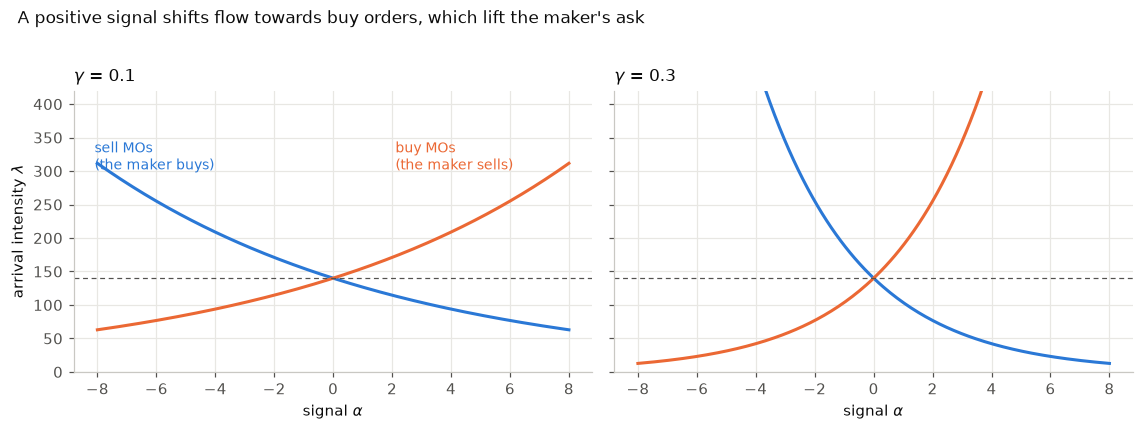

In [5]:
alpha_grid = np.linspace(-8, 8, 201)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)

for ax, sensitivity in zip(axes, (0.1, 0.3)):
    model = StateDependentPoissonArrivalModel(
        np.array([ARRIVAL_RATE, ARRIVAL_RATE]), sensitivity, ALPHA_INDEX, STEP_SIZE, len(alpha_grid))
    state = np.zeros((len(alpha_grid), 5))
    state[:, ALPHA_INDEX] = alpha_grid
    intensities = model.get_intensities(state)
    ax.plot(alpha_grid, intensities[:, 0], color=SELL_SIDE)
    ax.plot(alpha_grid, intensities[:, 1], color=BUY_SIDE)
    ax.axhline(ARRIVAL_RATE, color=MUTED, linewidth=0.8, linestyle=(0, (4, 3)))
    ax.set_title(f"$\\gamma$ = {sensitivity}", loc="left")
    ax.set_xlabel("signal $\\alpha$")

axes[0].set_ylabel("arrival intensity $\\lambda$")
axes[0].set_ylim(0, 3 * ARRIVAL_RATE)
axes[0].annotate("sell MOs\n(the maker buys)", (0.04, 0.72), xycoords="axes fraction", color=SELL_SIDE, fontsize=9)
axes[0].annotate("buy MOs\n(the maker sells)", (0.62, 0.72), xycoords="axes fraction", color=BUY_SIDE, fontsize=9)
fig.suptitle("A positive signal shifts flow towards buy orders, which lift the maker's ask",
             y=1.02, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

### 7.2 The markout curve

The markout is the empirical signature of adverse selection and the quantity practitioners measure:

$$m_h \;=\; \mathbb{E}\big[\Delta q_t \,\big(S_{t+h} - S_t\big)\big],$$

where $\Delta q_t$ is the change in inventory over $[t, t+1]$. It is negative when the price moves against the
position just taken. The vector $(m_h)_h$ is also the natural moment vector for simulated method of moments: it
over-identifies $\gamma$, which makes the over-identification test available as a specification test.

In [6]:
HORIZONS = (1, 2, 5, 10, 20, 50)
SENSITIVITIES = (0.0, 0.1, 0.2, 0.4)
SEEDS = (11, 22, 33, 44, 55)


def markouts(observations, horizons=HORIZONS):
    inventory_change = np.diff(observations[:, INVENTORY_INDEX, :], axis=1)
    price = observations[:, ASSET_PRICE_INDEX, :]
    usable = inventory_change.shape[1]
    return {h: float(np.mean(inventory_change[:, : usable - h]
                             * (price[:, h : h + usable - h] - price[:, : usable - h])))
            for h in horizons}


runs = {s: pd.DataFrame([markouts(rollout(get_env(500, seed, sensitivity=s), ConstantDepthAgent(500))["observations"])
                         for seed in SEEDS], index=SEEDS)
        for s in SENSITIVITIES}
markout_mean = pd.DataFrame({s: df.mean() for s, df in runs.items()})
markout_se = pd.DataFrame({s: df.std(ddof=1) / np.sqrt(len(SEEDS)) for s, df in runs.items()})
markout_mean.rename_axis("horizon h", axis=0).rename_axis("gamma", axis=1).round(5)

gamma,0.0,0.1,0.2,0.4
horizon h,,,,
1,-0.00003,-0.00213,-0.00275,-0.00323
2,-0.00012,-0.00424,-0.00550,-0.00643
5,-0.00015,-0.00961,-0.01248,-0.01467
10,-0.00003,-0.01691,-0.02205,-0.02604
20,0.00048,-0.02683,-0.03519,-0.04186
50,0.00175,-0.03768,-0.05023,-0.06029


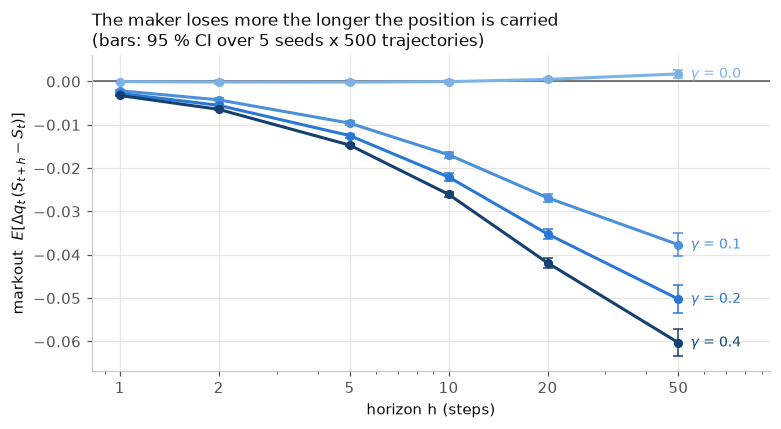

In [7]:
fig, ax = plt.subplots()
for colour, sensitivity in zip(RAMP, SENSITIVITIES):
    mean, se = markout_mean[sensitivity], markout_se[sensitivity]
    ax.errorbar(HORIZONS, mean, yerr=1.96 * se, color=colour, marker="o", markersize=5,
                capsize=3, elinewidth=1)
    ax.annotate(f"$\\gamma$ = {sensitivity}", (HORIZONS[-1], mean.iloc[-1]), color=colour, fontsize=9,
                xytext=(8, -3), textcoords="offset points")
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xscale("log")
ax.set_xticks(HORIZONS); ax.set_xticklabels(HORIZONS)
ax.set_xlabel("horizon h (steps)")
ax.set_ylabel("markout  $E[\\Delta q_t\\,(S_{t+h} - S_t)]$")
ax.set_title("The maker loses more the longer the position is carried\n"
             "(bars: 95 % CI over 5 seeds x 500 trajectories)", loc="left")
ax.set_xlim(right=95)
plt.tight_layout()

Three readings. At $\gamma = 0$ the curve is flat on zero: without the shared factor, executions are independent
of subsequent price moves. The curve decreases with the horizon, the shape observed on real data, because adverse
selection accumulates while the position is carried. And it is monotone in $\gamma$ but saturates — doubling
$\gamma$ from $0.2$ to $0.4$ adds about 20 %, because the arrival probability is bounded.

At $h = 50$ the estimator becomes strongly skewed and its $t$ statistic is not reliable; the unit test therefore
compares the two regimes by a ratio rather than by an absolute threshold.

## 8. The mechanical mechanism, and the one number that governs it

The adverse branch fires when the price move over a step clears the quoted depth. With a Brownian midprice that
move is $\mathcal{N}(0, \sigma^2 dt)$, so for a quote at depth $\delta$

$$\mathbb{P}(\text{adverse fill, one side, one step}) \;=\; 1 - \Phi(\rho), \qquad
\boxed{\;\rho \;=\; \frac{\delta}{\sigma\sqrt{dt}}\;}$$

$\rho$ is the quoted depth measured in standard deviations of the one-step price move, and it is the **only**
quantity that decides whether the correction does anything. The closed form quotes $\delta^* \approx 1/\kappa$,
so $\rho \approx 1/(\kappa\,\sigma\sqrt{dt})$: the mechanism is a joint statement about $\kappa$, $\sigma$ and
$dt$, not a switch.

The cell below checks the formula against the paper's own numbers. Their Table 3 gives $\sigma = 0.005$,
$dt = 1\,$s and a fixed spread $\Delta = 0.01$, so at the touch $\delta = \Delta/2$ and $\rho = 1$; their Table 4
reports 3950 adverse against 825 non-adverse fills on the ask.

In [8]:
def adverse_probability(rho):
    return 1 - stats.norm.cdf(rho)


paper = dict(sigma=0.005, dt=1.0, half_spread=0.005, intensity=0.1458, queue_probability=0.2)
rho_paper = paper["half_spread"] / (paper["sigma"] * np.sqrt(paper["dt"]))
predicted = adverse_probability(rho_paper) / (paper["intensity"] * paper["dt"] * paper["queue_probability"])

step_move = VOLATILITY * np.sqrt(STEP_SIZE)
rho_here = (1 / FILL_EXPONENT) / step_move

print(f"Lalor and Swishchuk (2024), Table 3-4")
print(f"  rho                                   = {rho_paper:.2f}")
print(f"  predicted adverse / non-adverse ratio = {predicted:.2f}")
print(f"  ratio reported in their Table 4       = {3950 / 825:.2f}")
print(f"\nThis notebook's parameters")
print(f"  one-step price move  sigma sqrt(dt)   = {step_move:.4f}")
print(f"  closed-form depth    1 / kappa        = {1 / FILL_EXPONENT:.4f}")
print(f"  rho                                   = {rho_here:.2f}")
print(f"  P(adverse fill per side per step)     = {adverse_probability(rho_here):.2e}")

Lalor and Swishchuk (2024), Table 3-4
  rho                                   = 1.00
  predicted adverse / non-adverse ratio = 5.44
  ratio reported in their Table 4       = 4.79

This notebook's parameters
  one-step price move  sigma sqrt(dt)   = 0.1414
  closed-form depth    1 / kappa        = 0.6667
  rho                                   = 4.71
  P(adverse fill per side per step)     = 1.21e-06


The first-principles calculation reproduces the paper's fill mix, which is the check that the mechanism has been
read correctly.

The second block is the consequential result, and it is a statement about **this environment**, not about the
paper. Lalor and Swishchuk calibrate on CME futures and land at $\rho = 1$, which is where a market maker
quoting at the touch of a real book actually sits. Our simulator quotes at $\rho = 4.7$: relative to its own
one-step volatility the closed form is resting almost five standard deviations away from the mid, so it is
essentially never run over. That is not evidence against the correction — it is evidence that the pairing of
$\kappa$ with $\sigma\sqrt{dt}$ inherited from Tests 1 and 2 is not a realistic microstructure, and $\rho$ is
the number that says so. Making the environment realistic means bringing $\kappa\,\sigma\sqrt{dt}$ towards one.

The next cell sweeps $\kappa$ to move $\rho$, holding $\sigma$ and $dt$ fixed, and reports the degradation of
both closed forms. The comparison is paired: for each $\kappa$ the same seeds are run with the branch off and on.

In [9]:
KAPPAS = [1.5, 3.0, 5.0, 7.0, 10.0, 15.0]
SWEEP_SEEDS = (7, 17, 27, 37, 47)
AS_RISK_AVERSION = 0.01


def score(agent_name, seeds=SWEEP_SEEDS, n=800, **env_kwargs):
    objective, pnl, adverse, non_adverse = [], [], 0.0, 0.0
    for seed in seeds:
        env = get_env(n, seed, with_alpha=False, **env_kwargs)
        agent = (CarteaJaimungalMmAgent(env=env) if agent_name == "CJ"
                 else AvellanedaStoikovAgent(risk_aversion=AS_RISK_AVERSION, env=env))
        out = rollout(env, agent)
        objective.append(out["objective"].mean()); pnl.append(out["pnl"].mean())
        adverse += out["adverse"]; non_adverse += out["non_adverse"]
    objective = np.array(objective)
    return dict(J=objective.mean(), J_se=objective.std(ddof=1) / np.sqrt(len(objective)),
                pnl=float(np.mean(pnl)), adverse_share=adverse / max(adverse + non_adverse, 1))


rows = []
for kappa in KAPPAS:
    for agent_name in ("CJ", "AS"):
        off = score(agent_name, fill_exponent=kappa, adverse_fills=False)
        on = score(agent_name, fill_exponent=kappa, adverse_fills=True)
        rows.append({"rho": (1 / kappa) / step_move, "kappa": kappa, "agent": agent_name,
                     "adverse share of fills": on["adverse_share"],
                     "PnL, branch off": off["pnl"], "PnL, branch on": on["pnl"],
                     "PnL change %": 100 * (on["pnl"] - off["pnl"]) / off["pnl"]})
sweep = pd.DataFrame(rows)
sweep.round(3)

/home/hamidou-diallo/Dev/Academic/deep_rl_market_making/src/agents/BaselineAgents.py:67: UserWarning: Avellaneda-Stoikov agent is quoting a negative spread
  warnings.warn("Avellaneda-Stoikov agent is quoting a negative spread")


,rho,kappa,agent,adverse share of fills,"PnL, branch off","PnL, branch on",PnL change %
0,4.714,1.5,CJ,0.004,67.772,67.784,0.019
1,4.714,1.5,AS,0.000,68.511,68.511,-0.001
2,2.357,3.0,CJ,0.045,33.897,33.764,-0.395
3,2.357,3.0,AS,0.039,34.075,33.940,-0.398
4,1.414,5.0,CJ,0.234,20.380,18.891,-7.309
5,1.414,5.0,AS,0.229,20.287,18.885,-6.912
6,1.010,7.0,CJ,0.375,14.588,11.180,-23.361
7,1.010,7.0,AS,0.372,14.348,11.166,-22.178
8,0.707,10.0,CJ,0.480,10.224,4.381,-57.154
9,0.707,10.0,AS,0.479,9.969,4.411,-55.751


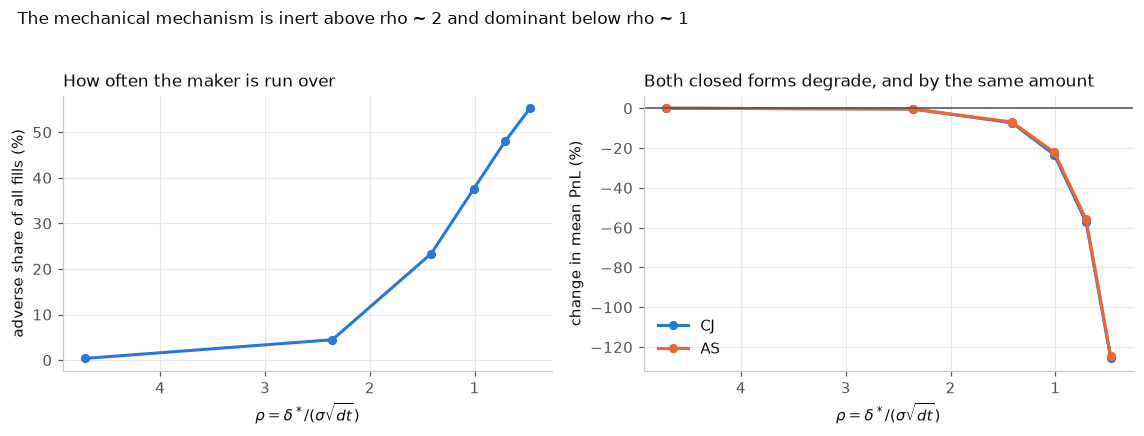

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
pivot_share = sweep.pivot_table(index="rho", columns="agent", values="adverse share of fills")
pivot_pnl = sweep.pivot_table(index="rho", columns="agent", values="PnL change %")

axes[0].plot(pivot_share.index, 100 * pivot_share["CJ"], color=RAMP[2], marker="o", markersize=5)
axes[0].set_ylabel("adverse share of all fills (%)")
axes[0].set_title("How often the maker is run over", loc="left")

for colour, agent_name in ((SELL_SIDE, "CJ"), (BUY_SIDE, "AS")):
    axes[1].plot(pivot_pnl.index, pivot_pnl[agent_name], color=colour, marker="o", markersize=5, label=agent_name)
axes[1].axhline(0, color=MUTED, linewidth=1)
axes[1].set_ylabel("change in mean PnL (%)")
axes[1].set_title("Both closed forms degrade, and by the same amount", loc="left")
axes[1].legend()

for ax in axes:
    ax.set_xlabel(r"$\rho = \delta^* / (\sigma\sqrt{dt})$")
    ax.invert_xaxis()
fig.suptitle("The mechanical mechanism is inert above rho ~ 2 and dominant below rho ~ 1",
             y=1.03, x=0.02, ha="left", fontsize=11)
plt.tight_layout()

In [11]:
gap = (pivot_pnl["CJ"] - pivot_pnl["AS"]).rename("CJ - AS, percentage points")
print("Degradation of the two closed forms, side by side\n")
print(pd.concat([pivot_pnl.round(1), gap.round(1)], axis=1).to_string())
print("\nThe gap never exceeds about 1.5 percentage points, against degradations that reach 126 %: the mechanism")
print("taxes the two closed forms alike. It is a degradation axis, not a discriminating one.")

Degradation of the two closed forms, side by side

             AS     CJ  CJ - AS, percentage points
rho                                               
0.471405 -124.7 -125.7                        -1.0
0.707107  -55.8  -57.2                        -1.4
1.010153  -22.2  -23.4                        -1.2
1.414214   -6.9   -7.3                        -0.4
2.357023   -0.4   -0.4                         0.0
4.714045   -0.0    0.0                         0.0

The gap never exceeds about 1.5 percentage points, against degradations that reach 126 %: the mechanism
taxes the two closed forms alike. It is a degradation axis, not a discriminating one.


Two caveats on the arms above, neither of which affects the conclusion but both of which affect how the numbers
should be read.

*The Avellaneda-Stoikov arm is scored on PnL only, not on $J$.* AS maximises the exponential utility of terminal
wealth, not the Cartea-Jaimungal criterion; scoring it on $J$ would measure a criterion mismatch rather than a
response to the fill mechanism. With `risk_aversion` small it also quotes a negative depth at large inventory --
hence the warning above -- and `ExponentialFillFunction` returns $e^{-\kappa\delta} > 1$ there, i.e. a certain
fill. The artefact is present identically in both arms of each paired comparison, so it largely cancels in the
degradation, but the AS levels themselves should not be read as a scorecard.

*The queue-position branch is held at $p = 1$ throughout this sweep.* Lalor and Swishchuk introduce it as a
second, independent correction and report its fill counts separately, but the two are varied together in their
results because both are calibrated to the same data. Here they are separated deliberately: at $\rho \approx 4.7$
setting $p = 0.2$ costs about 80 % of PnL while the adverse share of fills is still 0.4 %, so almost all of that
loss would be a reduction in trading volume rather than adverse selection, and attributing it to the latter would
be a measurement error of ours, not of theirs.

## 9. Is the mechanical mechanism avoidable?

Section 8 shows the correction is real and large. It does not show that a better agent could do anything about
it. The adverse fill fires on $S_{t+dt} - S_t = \alpha_t\,dt + \sigma\sqrt{dt}\,Z$, of which only the first term
is in the observation, so the predictable share of the move is bounded by

$$R^2 \;=\; \frac{\operatorname{Var}(\alpha)\,dt^2}{\operatorname{Var}(\alpha)\,dt^2 + \sigma^2 dt}
\;=\; \frac{\operatorname{Var}(\alpha)\,dt}{\operatorname{Var}(\alpha)\,dt + \sigma^2}.$$

Everything above that bound is a tax no policy can avoid except by quoting deeper and trading less. The cell
measures the bound, checks it empirically, and reports how much the adverse-fill rate actually moves across
deciles of the signal.

In [12]:
n = 3000
env = get_env(n, 7, sensitivity=0.2, fill_exponent=7.0, adverse_fills=True)
agent = CarteaJaimungalMmAgent(env=env)
obs = env.reset()
alphas, moves, adverse_ask = [], [], []
previous_price = obs[:, ASSET_PRICE_INDEX].copy()
for _ in range(env.n_steps):
    alphas.append(obs[:, ALPHA_INDEX].copy())
    obs, _, done, _ = env.step(agent.get_action(obs))
    moves.append(obs[:, ASSET_PRICE_INDEX] - previous_price)
    previous_price = obs[:, ASSET_PRICE_INDEX].copy()
    adverse_ask.append(env.model_dynamics.last_adverse_fills[:, ASK_INDEX].copy())
    if done[0]:
        break

alpha = np.concatenate(alphas); move = np.concatenate(moves); fired = np.concatenate(adverse_ask)
bound = alpha.var() * STEP_SIZE / (alpha.var() * STEP_SIZE + VOLATILITY ** 2)

edges = np.quantile(alpha, np.linspace(0, 1, 11))
bucket = np.clip(np.digitize(alpha, edges[1:-1]), 0, 9)
rates = np.array([fired[bucket == d].mean() for d in range(10)])

print(f"sd(alpha)                             = {alpha.std():.3f}")
print(f"predictable drift per step  alpha dt  = {alpha.std() * STEP_SIZE:.5f}")
print(f"diffusion per step  sigma sqrt(dt)    = {VOLATILITY * np.sqrt(STEP_SIZE):.5f}")
print(f"\nR^2 bound, analytic                   = {100 * bound:.2f} %")
print(f"R^2 of the step move on alpha, measured = {100 * np.corrcoef(alpha, move)[0, 1] ** 2:.2f} %")
print(f"\nask adverse-fill rate, lowest alpha decile  = {100 * rates[0]:.2f} %")
print(f"ask adverse-fill rate, highest alpha decile = {100 * rates[-1]:.2f} %")
print(f"ratio                                       = {rates[-1] / rates[0]:.2f}")

sd(alpha)                             = 4.422
predictable drift per step  alpha dt  = 0.02211
diffusion per step  sigma sqrt(dt)    = 0.14142

R^2 bound, analytic                   = 2.39 %
R^2 of the step move on alpha, measured = 2.41 %

ask adverse-fill rate, lowest alpha decile  = 14.80 %
ask adverse-fill rate, highest alpha decile = 16.73 %
ratio                                       = 1.13


Only about 2.4 % of the variance of the one-step price move is predictable, and the adverse-fill rate moves from
roughly 15 % to 17 % between the extreme deciles of the signal. **In this calibration the mechanical mechanism is
therefore close to an unavoidable tax**, which is the quantitative form of the paper's own caveat that "it's
extremely unlikely that any short-term alpha predictor could foresee all future adverse fills."

It belongs in the environment for the reason the paper gives — it stops the simulator from inflating the
strategy's performance — and the size of the effect measured in section 8 confirms that argument rather than
qualifying it. What section 9 adds is the ceiling: how much of the tax any policy could avoid here is set by
$\operatorname{Var}(\alpha)\,dt / \sigma^2$, and raising that ratio is a design lever if the environment is
meant to reward prediction.

## 10. Does the informational mechanism move the optimal control?

This is the question that decides whether the factor earns its place in the state. A factor can be massively
significant and still leave the optimal policy unchanged, in which case it can be dropped.

The test is direct. Take the closed form and add a one-parameter, signal-aware widening of the side the drift is
about to run into,

$$\tilde\delta^{+} = \delta^{+,*} + c\,\max(\alpha_t, 0)\,dt, \qquad
\tilde\delta^{-} = \delta^{-,*} + c\,\max(-\alpha_t, 0)\,dt,$$

with $c = 0$ recovering the closed form exactly. If $c$ earns nothing, the closed form is already optimal and the
factor is irrelevant to the control. The essential control is the second arm: a **symmetric** widening of the
same average size, which carries no signal. Whatever the symmetric arm earns is attributable to quoting wider,
not to the signal, and only the difference between the two is the value of the information.

In [13]:
class SignalAwareCj(Agent):
    """The closed form plus a one-parameter widening of the side the drift threatens."""

    def __init__(self, env, c):
        self.inner, self.c, self.dt = CarteaJaimungalMmAgent(env=env), c, env.step_size

    def get_action(self, state):
        action = self.inner.get_action(state)
        if self.c == 0.0:
            return action
        alpha = state[:, ALPHA_INDEX]
        action = action.copy()
        action[:, ASK_INDEX] += self.c * np.maximum(alpha, 0.0) * self.dt
        action[:, BID_INDEX] += self.c * np.maximum(-alpha, 0.0) * self.dt
        return action


class SymmetricCj(Agent):
    """The control: the same average widening, applied to both sides, carrying no information."""

    def __init__(self, env, widening):
        self.inner, self.widening = CarteaJaimungalMmAgent(env=env), widening

    def get_action(self, state):
        return self.inner.get_action(state) + self.widening


def evaluate(factory, sensitivity=0.2, adverse_fills=True, seeds=SWEEP_SEEDS, n=1000):
    objective, widening = [], []
    for seed in seeds:
        env = get_env(n, seed, sensitivity=sensitivity, fill_exponent=7.0, adverse_fills=adverse_fills)
        agent, reference = factory(env), CarteaJaimungalMmAgent(env=env)
        obs = env.reset()
        total = np.zeros(n)
        for _ in range(env.n_steps):
            action = agent.get_action(obs)
            widening.append(float((action - reference.get_action(obs)).mean()))
            obs, reward, done, _ = env.step(action)
            total += reward
            if done[0]:
                break
        objective.append(total.mean())
    objective = np.array(objective)
    return objective.mean(), objective.std(ddof=1) / np.sqrt(len(objective)), float(np.mean(widening))


rows = []
for adverse_fills in (True, False):
    for c in (0.0, 1.0, 2.0, 4.0):
        J_signal, se_signal, widening = evaluate(lambda e: SignalAwareCj(e, c), adverse_fills=adverse_fills)
        J_flat, se_flat, _ = evaluate(lambda e: SymmetricCj(e, widening), adverse_fills=adverse_fills)
        rows.append({"adverse fills": adverse_fills, "c": c, "mean widening": widening,
                     "J, signal-aware": J_signal, "J, symmetric control": J_flat,
                     "value of the signal": J_signal - J_flat,
                     "se": float(np.hypot(se_signal, se_flat))})
information = pd.DataFrame(rows)
information.round(3)

,adverse fills,c,mean widening,"J, signal-aware","J, symmetric control",value of the signal,se
0,True,0.0,0.000,-2.689,-2.689,0.000,0.338
1,True,1.0,0.009,1.145,-2.074,3.219,0.298
2,True,2.0,0.017,4.184,-1.412,5.596,0.273
3,True,4.0,0.035,8.542,-0.487,9.029,0.284
4,False,0.0,0.000,-6.982,-6.982,0.000,0.484
5,False,1.0,0.009,-1.637,-6.018,4.381,0.448
6,False,2.0,0.017,2.064,-5.101,7.165,0.385
7,False,4.0,0.035,6.660,-3.724,10.384,0.366


Two conclusions, and the second corrects a natural first guess.

**The informational mechanism moves the optimal control.** At matched average widening the signal-aware rule
beats the symmetric control by many standard errors. The closed form is not merely losing payoff in the enriched
environment, it is quoting the wrong depths, and a state it cannot see is what fixes them.

**The mechanical mechanism does not add to this.** The value of the signal is *larger* with the adverse branch
switched off than with it on. That is the same conclusion as section 9, reached independently: the adverse fills
are largely unforeseeable, so they dilute rather than reward the use of the signal.

## 11. The cost to the unchanged closed form

Finally, the headline comparison: the Cartea–Jaimungal control, unchanged, deployed in both environments on the
same evaluation trajectories.

A caveat on what this arm measures, and it is the reason a further arm exists. This is the **naive** closed form:
its four internal constants come from $E_{\text{closed}}$ and it never sees $\alpha$. What it measures is the
cost of misspecification, not the superiority of anything that might replace it.

In [14]:
rows = []
for seed in (13, 77, 404):
    for sensitivity, label in ((0.0, "E_closed  (gamma = 0)"), (0.2, "E_rich    (gamma = 0.2)")):
        env = get_env(2000, seed, sensitivity=sensitivity)
        out = rollout(env, CarteaJaimungalMmAgent(env=env))
        inventory = out["observations"][:, INVENTORY_INDEX, -1]
        rows.append({"seed": seed, "environment": label, "J": out["objective"].mean(),
                     "mean PnL": out["pnl"].mean(), "sd PnL": out["pnl"].std(),
                     "|terminal inventory|": np.abs(inventory).mean()})
results = pd.DataFrame(rows)
results.groupby("environment")[["J", "mean PnL", "sd PnL", "|terminal inventory|"]].mean().round(2)

,J,mean PnL,sd PnL,|terminal inventory|
environment,,,,
E_closed (gamma = 0),66.94,67.54,10.16,0.39
E_rich (gamma = 0.2),37.97,48.88,21.12,1.90


In [15]:
closed, rich = (results[results.environment.str.startswith(p)] for p in ("E_closed", "E_rich"))
print("Paired comparison, unchanged closed form, 3 seeds x 2000 trajectories\n")
for seed, a, b in zip(closed.seed, closed["mean PnL"], rich["mean PnL"]):
    print(f"  seed {seed:<5} PnL {a:+7.2f} -> {b:+7.2f}   ({100 * (b - a) / a:+.1f} %)")
print(f"\n  mean PnL          : {100 * (rich['mean PnL'].mean() / closed['mean PnL'].mean() - 1):+.1f} %")
print(f"  PnL volatility    : x{rich['sd PnL'].mean() / closed['sd PnL'].mean():.2f}")
print(f"  inventory carried : x{rich['|terminal inventory|'].mean() / closed['|terminal inventory|'].mean():.2f}")

Paired comparison, unchanged closed form, 3 seeds x 2000 trajectories

  seed 13    PnL  +67.45 ->  +48.81   (-27.6 %)
  seed 77    PnL  +67.32 ->  +48.61   (-27.8 %)
  seed 404   PnL  +67.84 ->  +49.21   (-27.5 %)

  mean PnL          : -27.6 %
  PnL volatility    : x2.08
  inventory carried : x4.84


## 12. What this environment is not

Everything above measures adverse selection *inside* this simulator. Whether those measurements transfer depends
on how far the simulator sits from a real book, and that is a question about parameters rather than about
mechanisms. The cell below puts every parameter into units that can be compared to one, and the answer is
uncomfortable enough to be worth stating in the notebook rather than in a footnote.

In [16]:
half_spread = 1 / FILL_EXPONENT
per_step_move = VOLATILITY * np.sqrt(STEP_SIZE)
alpha_sd = ALPHA_VOLATILITY * np.sqrt(STEP_SIZE) / np.sqrt(1 - (1 - ALPHA_SPEED) ** 2)
fills_per_episode = 2 * N_STEPS * ARRIVAL_RATE * STEP_SIZE * np.exp(-1)

audit = pd.DataFrame([
    ("half-spread quoted, 1/kappa", f"{1e4 * half_spread / 100:.0f} bp", "liquid future: about 0.5 bp"),
    ("volatility per step", f"{1e4 * per_step_move / 100:.1f} bp", f"{1e4 * VOLATILITY / 100:.0f} bp per episode"),
    ("rho = half-spread / step move", f"{half_spread / per_step_move:.2f}", "real book: about 1"),
    ("arrivals, lambda dt", f"{ARRIVAL_RATE * STEP_SIZE:.2f} per side per step", "one order every 1.4 steps"),
    ("fills per episode", f"{fills_per_episode:.0f}", "measured: 95.5"),
    ("gross spread revenue", f"{1e4 * fills_per_episode * half_spread / 100:.0f} bp of notional",
     "a market maker earns basis points"),
    ("sd of the latent factor", f"{alpha_sd:.2f}", f"drift per step {alpha_sd * STEP_SIZE:.4f}"),
    ("intensity tilt at one sd", f"x{np.exp(2 * 0.2 * alpha_sd):.1f}", "ratio of the two arrival rates"),
], columns=["quantity", "this simulator", "for comparison"])
print(audit.to_string(index=False))

print("\n\nWhat adverse selection can cost here, as a share of the edge per fill\n")
for horizon, label in ((1, "one step"), (5, "five steps")):
    move = VOLATILITY * np.sqrt(horizon * STEP_SIZE)
    print(f"  typical move over {label:<11} {move:.3f}   {100 * move / half_spread:5.0f} % of the edge")
print(f"  measured markout per fill    {-0.034:.3f}   {100 * 0.034 / half_spread:5.0f} % of the edge")
print(f"\n  P(price trades through the quote in one step) = {1 - stats.norm.cdf(half_spread / per_step_move):.1e}")
print(f"  the same probability at rho = 1               = {1 - stats.norm.cdf(1.0):.3f}")

                     quantity         this simulator                    for comparison
  half-spread quoted, 1/kappa                  67 bp       liquid future: about 0.5 bp
          volatility per step                14.1 bp                200 bp per episode
rho = half-spread / step move                   4.71                real book: about 1
          arrivals, lambda dt 0.70 per side per step         one order every 1.4 steps
            fills per episode                    103                    measured: 95.5
         gross spread revenue    6867 bp of notional a market maker earns basis points
      sd of the latent factor                   4.53             drift per step 0.0226
     intensity tilt at one sd                   x6.1    ratio of the two arrival rates


What adverse selection can cost here, as a share of the edge per fill

  typical move over one step    0.141      21 % of the edge
  typical move over five steps  0.316      47 % of the edge
  measured markout per f

Read together, those numbers say one thing: **the spread is about a hundred and thirty times too wide relative to
this simulator's own volatility.** Everything else follows from it. Each fill is so profitable that the strategy
returns tens of per cent of notional per episode; adverse selection, measured at five per cent of the edge per
fill, can only ever nibble; and the price trades through a resting quote with probability $10^{-6}$ rather than
the $0.16$ a book at $\rho = 1$ would give.

**The consequence for what sections 7 to 11 establish.** They measure the *informational* mechanism -- a flow
imbalance an agent can learn to predict -- in a regime where the *mechanical* one is numerically absent. Those are
different problems. Predicting which side of the book is about to be hit is a forecasting problem; surviving a
price that runs through your quote is a spread-setting problem, and no amount of forecasting removes it. Only the
first has been exercised here.

**And the signal is generous.** At one standard deviation of the factor the two arrival intensities differ by a
factor of six. Order-flow predictability in real data is far weaker than that, so $\gamma = 0.2$ should be read as
an easy regime and $\gamma = 0.4$ as an extreme one, not as a central case.

**What the simulator does not contain at all**, verified against the constructed object rather than assumed: price
impact from the agent's own trades, a tick size, order sizes (every fill is one unit), queue position, partial
fills, cancellations, and any clustering of arrivals. Each is a channel through which a real book penalises a
market maker, and none of them is in the measurements above.

## 13. What this notebook establishes

| Result | Evidence |
|---|---|
| The enriched environment nests the closed-form one | trajectories identical bit for bit at $\gamma = 0$, four seeds |
| The informational mechanism produces adverse selection | markout negative, decreasing in $h$, monotone in $\gamma$, 95 % CIs clear of zero |
| That adverse selection is predictable | $\alpha$ observable, lag-one autocorrelation $\approx 0.95$ |
| **It moves the optimal control** | a signal-aware widening beats a symmetric widening of equal size by many standard errors |
| The unchanged closed form pays for it | mean PnL $\approx -28\,\%$, PnL volatility roughly doubled, stable across seeds |
| The mechanical mechanism is governed by $\rho$ alone | $1 - \Phi(\rho)$ reproduces the fill mix of Lalor and Swishchuk's Table 4 |
| This environment sits far from the realistic regime | $\rho = 4.7$ against $\rho = 1$ on CME data; adverse share $0.4\,\%$, PnL change $+0.05\,\%$ |
| Where it bites it taxes CJ and AS equally | gap in PnL degradation $\leq 1.5$ points, against degradations reaching 126 % |
| And it is close to unavoidable | $R^2$ of the step move on $\alpha$ is 2.4 %; fill rate moves 15 % $\to$ 17 % across signal deciles |

**What follows for the design.** The two mechanisms play different roles and both belong in the environment, for
different reasons. The informational one creates a control problem the closed form cannot express, and is
therefore what a learned agent could win on. The mechanical one keeps the simulator honest about execution; its
effect is to lower every arm's payoff, including the learned one's, which is exactly why leaving it out inflates
any result obtained in this environment.

The degradation of the two closed forms in sections 8 and 11 is not a surprise and is not meant to be one — it is
visible in their formulas, which carry no state through which either mechanism could enter. It is used here as
**empirical evidence that the environment behaves as it should**: an environment in which a misspecified optimal
control did *not* degrade would be an environment that had failed to implement the relaxation it claims to.

**What is not established.**

1. **Calibration.** $\gamma = 0.2$ and $\rho$ are still chosen, not fitted. The markout curve of section 7.2 is
   the moment vector; fitting $\gamma$ by simulated method of moments against empirical markouts, and reading the
   over-identification statistic, would turn "the mechanism exists" into "the mechanism reproduces the data".
2. **The queue-position branch.** $p < 1$ was held at 1 throughout section 8, because at $\rho \approx 4.7$ its
   effect is almost entirely a reduction in trading volume rather than adverse selection, and mixing the two would
   confound the measurement. It needs its own treatment.
3. **The upper bound.** The residual left to a learned agent is bounded above by what a policy with oracle access
   to $\alpha$ achieves. Until that is measured, the gap between the closed form and any agent is not decomposed
   into what is capturable and what is irreducible.